# NLLB Finetune

In [1]:
!pip install evaluate -q
!pip install sacrebleu -q
!pip install torch>=2.11.0 torchao --index-url https://download.pytorch.org/whl/cu128 -q
# !pip install bert-score -q
!pip install unbabel-comet -q
!pip install torchao==0.16.0 -q
!pip install ctranslate2 -q

In [2]:
import os


os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

!pip uninstall tensorflow tensorflow-gpu tensorflow-estimator -y 2>/dev/null

!pip install protobuf==4.25.8 -q

## Анализ датасета

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback
import ctranslate2
import time
from sentence_transformers import SentenceTransformer
import evaluate
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
import gc
from peft import LoraConfig, get_peft_model, TaskType
# from bert_score import score as bert_score
# from bert_score import utils
from comet import download_model, load_from_checkpoint
from transformers import GenerationConfig
import shutil

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [4]:
model_name = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang="eng_Latn", tgt_lang="rus_Cyrl")
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
# model.eval()

In [5]:
with open('/kaggle/input/datasets/denccchicck/nllb-data/nllb_data.jsonl', 'r', encoding='utf-8') as f:
    pairs = [json.loads(line) for line in f]

print(f"Загружено пар: {len(pairs)}")

Загружено пар: 1000


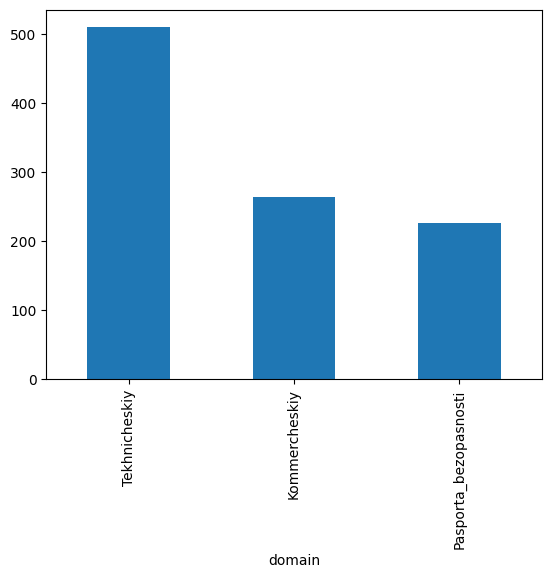

In [6]:
df = pd.DataFrame(pairs)

domain_counts = df['domain'].value_counts()
domain_counts.plot(kind='bar')
plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
model.eval()

def compute_loss(en_text, ru_text):
    en_tokens = tokenizer(en_text, return_tensors="pt", truncation=True, max_length=512)
    ru_tokens = tokenizer(ru_text, return_tensors="pt", truncation=True, max_length=512)

    # Переносим тензоры на то же устройство, что и модель
    en_tokens = {k: v.to(device) for k, v in en_tokens.items()}
    ru_tokens = {k: v.to(device) for k, v in ru_tokens.items()}

    with torch.no_grad():
        outputs = model(
            input_ids=en_tokens['input_ids'],
            attention_mask=en_tokens['attention_mask'],
            labels=ru_tokens['input_ids']
        )

    return outputs.loss.item()

losses = []
for pair in tqdm(pairs, desc="Computing loss"):
    en = pair.get('en', '')
    ru = pair.get('ru', '')
    if en and ru:
        try:
            loss = compute_loss(en, ru)
            losses.append({
                'en': en,
                'ru': ru,
                'loss': loss,
                'domain': pair.get('domain', 'Unknown'),
            })
        except Exception as e:
            print(f"Error: {e}")
            continue

Computing loss:   0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
df = pd.DataFrame(losses)

<Axes: xlabel='loss', ylabel='Count'>

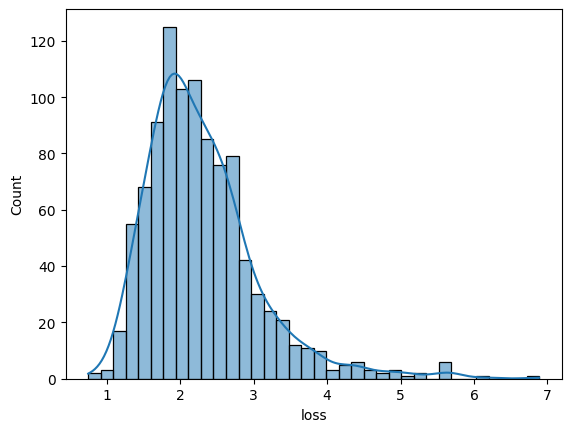

In [10]:
loss_vals = df['loss']

sns.histplot(loss_vals, kde=True)

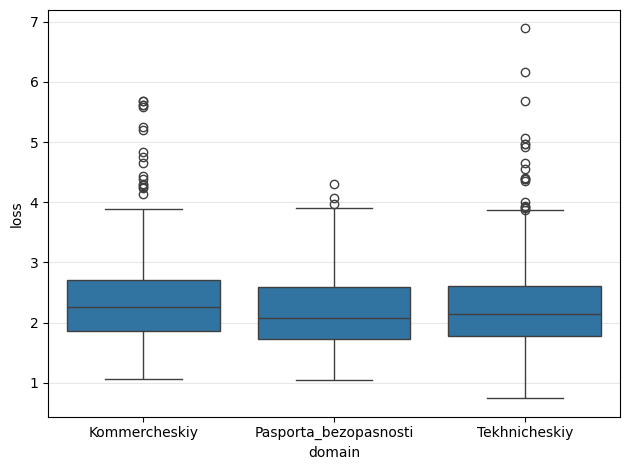

In [11]:
sns.boxplot(data=df, x='domain', y='loss')

plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

In [ ]:
model_st = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)

def compute_similarity(en_text, ru_text):
    """Вычисляет косинусное сходство между EN и RU эмбеддингами"""
    en_emb = model_st.encode([en_text], convert_to_tensor=True)
    ru_emb = model_st.encode([ru_text], convert_to_tensor=True)

    similarity = cosine_similarity(en_emb.cpu().numpy(), ru_emb.cpu().numpy())[0][0]
    return similarity

results = []
for pair in tqdm(pairs, desc="Computing similarity"):
    en = pair.get('en', '')
    ru = pair.get('ru', '')
    if en and ru:
        try:
            similarity = compute_similarity(en, ru)
            results.append({
                'en': en,
                'ru': ru,
                'similarity': similarity,
                'domain': pair.get('domain', 'Unknown'),
            })
        except Exception as e:
            print(f"Error: {e}")
            continue

print(f"Вычислено сходств: {len(results)}")

In [ ]:
df_st = pd.DataFrame(results)
df_st.sort_values(by='similarity')

In [14]:
df_st.describe()

,similarity
count,993.000000
mean,0.856835
std,0.065937
min,0.270786
25%,0.812292
50%,0.863486
75%,0.903450
max,0.990490


<Axes: ylabel='Count'>

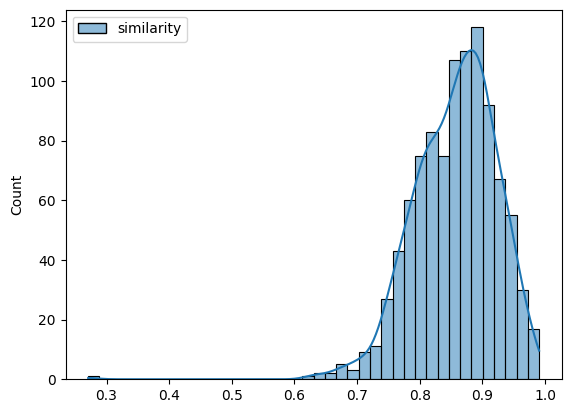

In [15]:
sns.histplot(df_st, kde=True)

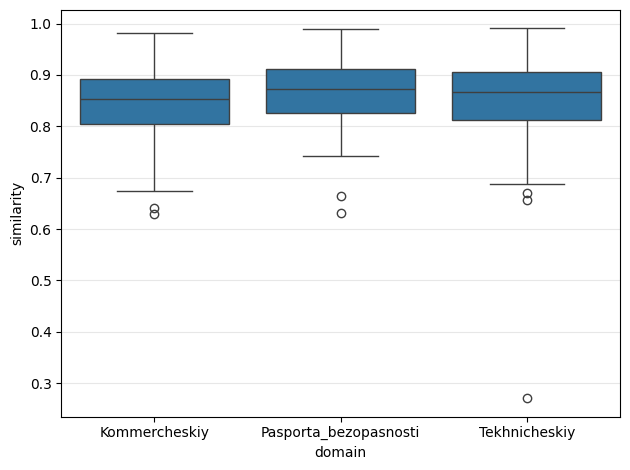

In [ ]:
sns.boxplot(data=df_st, x='domain', y='similarity')

plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

## Предобработка

In [17]:
filtered_pairs = []
for i, (pair, res, loss_dict) in enumerate(zip(pairs, results, losses)):
    if res['similarity'] >= 0.7 and loss_dict['loss'] <= 3.5:
        filtered_pairs.append(pair)

print(f"Оригинальное количество пар: {len(pairs)}")
print(f"Отфильтрованное количество пар: {len(filtered_pairs)}")

df = pd.DataFrame(filtered_pairs)

Оригинальное количество пар: 1000
Отфильтрованное количество пар: 920


EN Токены: 95% < 60 | 99% < 74 | Max = 97
RU Токены: 95% < 78 | 99% < 102 | Max = 246


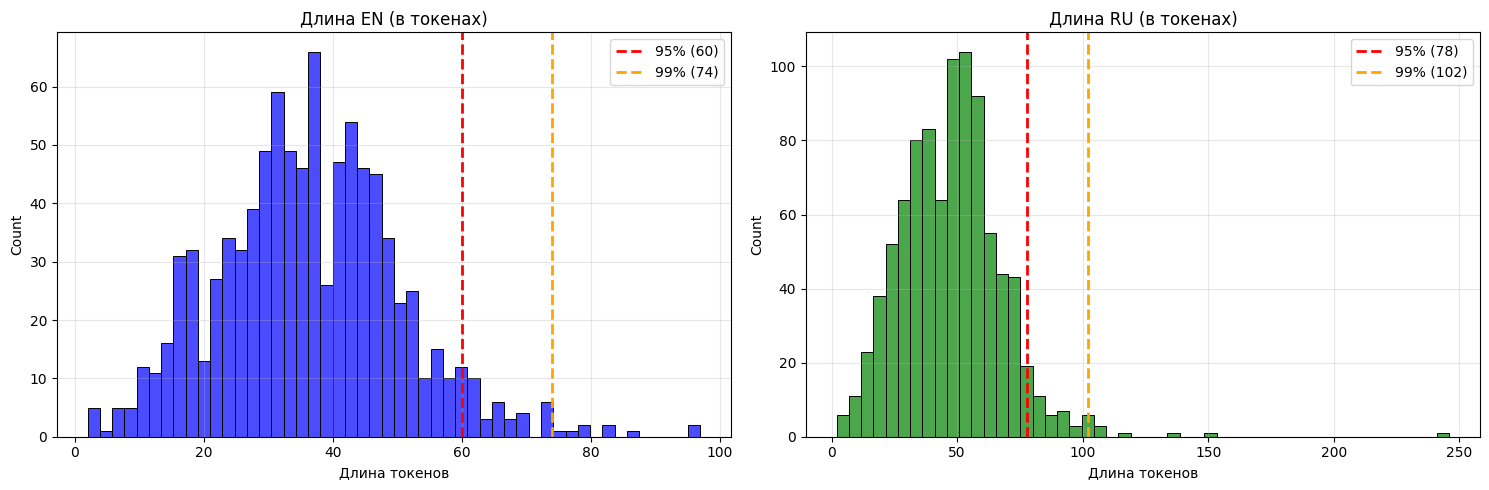

Устанавливаем MAX_LENGTH = 112


In [ ]:
en_lengths = [len(tokenizer.encode(text)) for text in df['en'].tolist()]
ru_lengths = [len(tokenizer.encode(text)) for text in df['ru'].tolist()]

en_95 = int(np.percentile(en_lengths, 95))
ru_95 = int(np.percentile(ru_lengths, 95))
en_99 = int(np.percentile(en_lengths, 99))
ru_99 = int(np.percentile(ru_lengths, 99))

print(f"EN Токены: 95% < {en_95} | 99% < {en_99} | Max = {max(en_lengths)}")
print(f"RU Токены: 95% < {ru_95} | 99% < {ru_99} | Max = {max(ru_lengths)}")

length_df = pd.DataFrame({
    'Длина токенов': en_lengths + ru_lengths,
    'Язык': ['EN'] * len(en_lengths) + ['RU'] * len(ru_lengths)
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=length_df[length_df['Язык'] == 'EN'],
             x='Длина токенов', bins=50, color='blue', alpha=0.7, ax=axes[0])
axes[0].axvline(en_95, color='red', linestyle='dashed', linewidth=2, label=f'95% ({en_95})')
axes[0].axvline(en_99, color='orange', linestyle='dashed', linewidth=2, label=f'99% ({en_99})')
axes[0].set_title("Длина EN (в токенах)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.histplot(data=length_df[length_df['Язык'] == 'RU'],
             x='Длина токенов', bins=50, color='green', alpha=0.7, ax=axes[1])
axes[1].axvline(ru_95, color='red', linestyle='dashed', linewidth=2, label=f'95% ({ru_95})')
axes[1].axvline(ru_99, color='orange', linestyle='dashed', linewidth=2, label=f'99% ({ru_99})')
axes[1].set_title("Длина RU (в токенах)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MAX_LENGTH = min(256, max(en_99, ru_99) + 10)
print(f"Устанавливаем MAX_LENGTH = {MAX_LENGTH}")

In [ ]:
df['length_bin'] = pd.qcut(df['ru'].apply(len), q=3, labels=['short', 'medium', 'long'])

df['stratify_key'] = df['domain'] + "_" + df['length_bin'].astype(str)

counts = df['stratify_key'].value_counts()
rare_keys = counts[counts < 2].index
df.loc[df['stratify_key'].isin(rare_keys), 'stratify_key'] = 'other'

# Сначала разделяем на train (80%) и temp (20%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['stratify_key'],
    random_state=42
)

# Потом temp делим на val (7.5%) и test (12.5%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.625,
    stratify=temp_df['stratify_key'],
    random_state=42
)

print(f"Размер Train: {len(train_df)} пар ({len(train_df)/len(df)*100:.1f}%)")
print(f"Размер Val:   {len(val_df)} пар ({len(val_df)/len(df)*100:.1f}%)")
print(f"Размер Test:  {len(test_df)} пар ({len(test_df)/len(df)*100:.1f}%)")

hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[['en', 'ru']]),
    "validation": Dataset.from_pandas(val_df[['en', 'ru']]),
    "test": Dataset.from_pandas(test_df[['en', 'ru']])
})

def preprocess_function(examples):
    inputs = tokenizer(examples["en"], max_length=MAX_LENGTH, truncation=True)

    targets = tokenizer(text_target=examples["ru"], max_length=MAX_LENGTH, truncation=True)

    labels = targets["input_ids"]
    labels = [[-100 if token == tokenizer.pad_token_id else token for token in l] for l in labels]

    inputs["labels"] = labels
    return inputs

print("Токенизация датасета для обучения...")
tokenized_datasets = hf_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=hf_dataset["train"].column_names
)

print(f"Train размер: {len(tokenized_datasets['train'])}")
print(f"Validation размер: {len(tokenized_datasets['validation'])}")
print(f"Test размер: {len(tokenized_datasets['test'])}")

Размер Train: 736 пар (80.0%)
Размер Val:   69 пар (7.5%)
Размер Test:  115 пар (12.5%)
Токенизация датасета для обучения...


Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

Map:   0%|          | 0/115 [00:00<?, ? examples/s]

Train размер: 736
Validation размер: 69
Test размер: 115


In [ ]:
metric_chrf = evaluate.load("chrf")
metric_bleu = evaluate.load("sacrebleu")

def compute_metrics(eval_preds):
    preds = eval_preds.predictions
    labels = eval_preds.label_ids

    if isinstance(preds, tuple):
        preds = preds[0]


    # Если Trainer почему-то вернул logits вместо token IDs
    if preds.ndim == 3:
        print("WARNING: predictions are LOGITS, not generated token IDs!")
        return {
            "chrf": 0.0,
            "bleu": 0.0
        }

    preds = np.asarray(preds, dtype=np.int64)
    labels = np.asarray(labels, dtype=np.int64)

    # Это предотвращает OverflowError при декодировании
    preds = np.where(preds == -100, tokenizer.pad_token_id, preds)

    # Также заменяем -100 в лейблах (хотя они уже могли быть обработаны)
    labels = np.where(labels == -100, tokenizer.pad_token_id, labels)

    # Декодируем предсказания и лейблы
    decoded_preds = tokenizer.batch_decode(
        preds,
        skip_special_tokens=True
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )


    decoded_preds = [
        pred.strip() if pred.strip() else "пусто"
        for pred in decoded_preds
    ]

    decoded_labels = [
        [label.strip() if label.strip() else "пусто"]
        for label in decoded_labels
    ]

    chrf_result = metric_chrf.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    bleu_result = metric_bleu.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    print(
        f"chrF={chrf_result['score']:.4f}, "
        f"BLEU={bleu_result['score']:.4f}"
    )

    return {
        "chrf": chrf_result["score"],
        "bleu": bleu_result["score"]
    }

In [21]:
test_en = test_df['en'].tolist()
test_ru = test_df['ru'].tolist()
print(f"Тестовых примеров: {len(test_en)}")

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16
).to(device)
base_model.eval()

tokenizer.src_lang = "eng_Latn"
tokenizer.tgt_lang = "rus_Cyrl"
rus_token_id = tokenizer.convert_tokens_to_ids("rus_Cyrl")
print(f"rus_Cyrl token ID: {rus_token_id}")

`torch_dtype` is deprecated! Use `dtype` instead!


Тестовых примеров: 115
rus_Cyrl token ID: 256147


In [ ]:
predictions = []

batch_size = 16
for i in tqdm(range(0, len(test_en), batch_size), desc="Базовая модель"):
    batch_en = test_en[i:i+batch_size]

    inputs = tokenizer(
        batch_en,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            forced_bos_token_id=rus_token_id,
            max_new_tokens=MAX_LENGTH,
            num_beams=2,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    batch_preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    predictions.extend(batch_preds)

print("Вычисление метрик для базовой модели...")
references = [[ref] for ref in test_ru]

try:
    baseline_chrf = metric_chrf.compute(
        predictions=predictions,
        references=references
    )["score"]
    print(f"chrF: {baseline_chrf:.2f}")
except Exception as e:
    print(f"Ошибка при вычислении chrF: {e}")
    baseline_chrf = 0.0

try:
    baseline_bleu = metric_bleu.compute(
        predictions=predictions,
        references=references
    )["score"]
    print(f"BLEU: {baseline_bleu:.2f}")
except Exception as e:
    print(f"Ошибка при вычислении BLEU: {e}")
    baseline_bleu = 0.0

print("Загрузка COMET модели...")
comet_model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_model_path)

def compute_comet(predictions, references, sources, batch_size=16):
    safe_predictions = [p if p.strip() else "." for p in predictions]
    safe_references = [r if r.strip() else "." for r in references]
    safe_sources = [s if s.strip() else "." for s in sources]

    data = [
        {"src": src, "mt": pred, "ref": ref}
        for src, pred, ref in zip(safe_sources, safe_predictions, safe_references)
    ]

    comet_output = comet_model.predict(data, batch_size=batch_size, gpus=1 if torch.cuda.is_available() else 0)

    return {
        "scores": comet_output.scores,
        "mean_score": np.mean(comet_output.scores),
        "std_score": np.std(comet_output.scores)
    }

print("Вычисление COMET для базовой модели...")
comet_baseline = compute_comet(
    predictions=predictions,
    references=test_ru,
    sources=test_en,
    batch_size=16
)

baseline_comet = comet_baseline["mean_score"]
print(f"COMET: {baseline_comet:.4f}")

print(f"Количество примеров: {len(predictions)}")
print(f"chrF:           {baseline_chrf:.2f}")
print(f"BLEU:           {baseline_bleu:.2f}")
print(f"COMET:          {baseline_comet:.4f}")

baseline_metrics = {
    'chrf': baseline_chrf,
    'bleu': baseline_bleu,
    'comet': baseline_comet,
    'n_samples': len(predictions)
}

Базовая модель:   0%|          | 0/8 [00:00<?, ?it/s]

Вычисление метрик для базовой модели...
chrF: 55.21
BLEU: 29.80
Загрузка COMET модели...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
Encoder model frozen.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoin

Вычисление COMET для базовой модели...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Predicting DataLoader 0: 100%|██████████| 8/8 [00:04<00:00,  1.74it/s]


COMET: 0.7728
Количество примеров: 115
chrF:           55.21
BLEU:           29.80
COMET:          0.7728


In [23]:
del base_model

# 1. Удаляем модель и все тензоры
# del model
# del trainer

# 2. Запускаем сборщик мусора Python
gc.collect()

# 3. Очищаем кэш CUDA
torch.cuda.empty_cache()

# 4. Синхронизируем GPU
torch.cuda.synchronize()

## LoRA finetuning

In [24]:
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    dtype=torch.float16
)

rus_token_id = tokenizer.convert_tokens_to_ids("rus_Cyrl")

print("rus_token_id:", rus_token_id)
print("vocab_size:", model.config.vocab_size)
print("generation forced BOS:",
      model.generation_config.forced_bos_token_id)

generation_config = GenerationConfig.from_model_config(model.config)
generation_config.forced_bos_token_id = rus_token_id
# generation_config.decoder_start_token_id = rus_token_id
generation_config.pad_token_id = tokenizer.pad_token_id

model.generation_config = generation_config

rus_token_id: 256147
vocab_size: 256206
generation forced BOS: None


In [25]:
model = model.to(device)
model.eval()

text = test_df.iloc[0]["en"]

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_LENGTH
).to(device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        forced_bos_token_id=rus_token_id,
        max_new_tokens=100,
        num_beams=2
    )

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj", "fc1", "fc2"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./nllb_lora_mom",
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    lr_scheduler_type="cosine",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.05,
    warmup_steps=int(len(tokenized_datasets["train"]) / 8 * 0.1),
    num_train_epochs=12,
    predict_with_generate=True,
    generation_max_length=MAX_LENGTH,
    fp16=True,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="chrf",
    greater_is_better=True,
    report_to="none",
    remove_unused_columns=False
)

sample = test_df.iloc[0]["en"]

inputs = tokenizer(sample, return_tensors="pt").to(model.device)

out = model.generate(
    **inputs,
    max_new_tokens=50,
)

# print(tokenizer.decode(out[0], skip_special_tokens=True))

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Старт обучения LoRA...")
trainer.train()

print("Сохранение...")
trainer.save_model("./nllb_lora_final")
tokenizer.save_pretrained("./nllb_lora_final")
print("Обучение успешно завершено!")

trainable params: 8,650,752 || all params: 623,724,544 || trainable%: 1.3870
Старт обучения LoRA...


Epoch,Training Loss,Validation Loss,Chrf,Bleu
1,1.308800,1.084989,61.243736,35.655977
2,1.108100,1.049630,62.955469,37.839961
3,0.956800,1.041948,62.878267,38.104182
4,0.823100,1.039517,63.815745,41.231696
5,0.732000,1.055452,63.901070,39.735150
6,0.659800,1.074109,63.517947,40.387987
7,0.599200,1.081211,64.391473,41.259954
8,0.559500,1.096437,64.151500,40.541188
9,0.523600,1.099609,64.059585,40.646375
10,0.505700,1.099524,63.748403,40.393177


chrF=61.2437, BLEU=35.6560
chrF=62.9555, BLEU=37.8400
chrF=62.8783, BLEU=38.1042
chrF=63.8157, BLEU=41.2317
chrF=63.9011, BLEU=39.7352
chrF=63.5179, BLEU=40.3880
chrF=64.3915, BLEU=41.2600
chrF=64.1515, BLEU=40.5412
chrF=64.0596, BLEU=40.6464
chrF=63.7484, BLEU=40.3932
Сохранение...
Обучение успешно завершено!


## Расчет метрик

In [ ]:
model.eval()
finetuned_predictions = []

for i in tqdm(range(0, len(test_en), batch_size), desc="Testing LoRA"):
    batch_en = test_en[i:i+batch_size]

    inputs = tokenizer(
        batch_en,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            forced_bos_token_id=rus_token_id,
            max_new_tokens=MAX_LENGTH,
            num_beams=2,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    batch_preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    finetuned_predictions.extend(batch_preds)

print("Вычисление классических метрик для LoRA...")
references = [[ref] for ref in test_ru]

try:
    finetuned_chrf = metric_chrf.compute(predictions=finetuned_predictions, references=references)["score"]
except Exception as e:
    print(f"Ошибка chrF: {e}")
    finetuned_chrf = 0.0

try:
    finetuned_bleu = metric_bleu.compute(predictions=finetuned_predictions, references=references)["score"]
except Exception as e:
    print(f"Ошибка BLEU: {e}")
    finetuned_bleu = 0.0

print("Вычисление COMET для LoRA...")
comet_finetuned = compute_comet(
    predictions=finetuned_predictions,
    references=test_ru,
    sources=test_en,
    batch_size=16
)

finetuned_comet = comet_finetuned["mean_score"]
print(f"COMET: {finetuned_comet:.4f}")

print(f"chrF:           {finetuned_chrf:.2f}  (Было: {baseline_metrics['chrf']:.2f})  | Рост: {finetuned_chrf - baseline_metrics['chrf']:+.2f}")
print(f"BLEU:           {finetuned_bleu:.2f}  (Было: {baseline_metrics['bleu']:.2f})  | Рост: {finetuned_bleu - baseline_metrics['bleu']:+.2f}")
print(f"COMET:          {finetuned_comet:.4f}  (Было: {baseline_metrics['comet']:.4f})  | Рост: {finetuned_comet - baseline_metrics['comet']:+.4f}")

Testing LoRA:   0%|          | 0/8 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Вычисление классических метрик для LoRA...
Вычисление COMET для LoRA...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Predicting DataLoader 0: 100%|██████████| 8/8 [00:05<00:00,  1.52it/s]


COMET: 0.8192
chrF:           66.40  (Было: 55.21)  | Рост: +11.19
BLEU:           43.07  (Было: 29.80)  | Рост: +13.27
COMET:          0.8192  (Было: 0.7728)  | Рост: +0.0465


## Постпроцессинг и подготовка к деплою

In [ ]:
from peft import PeftModel


gc.collect()
torch.cuda.empty_cache()

base_model_name = "facebook/nllb-200-distilled-600M"
lora_path = "./nllb_lora_final"
merged_path = "./nllb_merged_full"

print("1. Загружаем чистую базовую модель на CPU...")
# Загружаем в float32, чтобы при конвертации в int8 не было потери точности
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float32,
    device_map="cpu"
)
tokenizer = AutoTokenizer.from_pretrained(base_model_name, src_lang="eng_Latn", tgt_lang="rus_Cyrl")

print("2. Прикрепляем LoRA адаптеры...")
peft_model = PeftModel.from_pretrained(base_model, lora_path)

print("3. Вшиваем веса LoRA в базовые матрицы (merge_and_unload)...")
merged_model = peft_model.merge_and_unload()

print("4. Сохраняем готовую полноценную модель...")
merged_model.save_pretrained(merged_path)
tokenizer.save_pretrained(merged_path)

print(f"Модель успешно слита и сохранена в {merged_path}!")

del base_model
del peft_model
del merged_model
gc.collect()

1. Загружаем чистую базовую модель на CPU...
2. Прикрепляем LoRA адаптеры...
3. Вшиваем веса LoRA в базовые матрицы (merge_and_unload)...
4. Сохраняем готовую полноценную модель...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Модель успешно слита и сохранена в ./nllb_merged_full!


316

In [42]:
!ct2-transformers-converter \
    --model ./nllb_merged_full \
    --output_dir ./nllb_ct2_int8_mom \
    --quantization int8 \
    --low_cpu_mem_usage \
    --force

print("Папка ./nllb_ct2_int8_mom готова к деплою")

Конвертируем модель в CTranslate2...
The tokenizer you are loading from './nllb_merged_full' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Папка ./nllb_ct2_int8_mom готова к деплою


In [45]:
model_dir = "./nllb_ct2_int8_mom"

print("Загрузка квантизованной модели в оперативную память (CPU)...")
translator = ctranslate2.Translator(model_dir, device="cpu", compute_type="int8")

tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M", src_lang="eng_Latn")

Загрузка квантизованной модели в оперативную память (CPU)...


In [46]:
# 1. Запускаем конвертер с флагом --force (чтобы можно было перезапускать ячейку)
os.system("ct2-transformers-converter --model ./nllb_merged_full --output_dir ./nllb_ct2_int8_mom --quantization int8 --low_cpu_mem_usage --force")

print("Квантизация весов завершена!")

# 2. Сохраняем токенизатор напрямую в папку CTranslate2 через Python.
# Это гарантирует, что сохранятся ИМЕННО ТЕ файлы, которые нужны NLLB, без гадания на bash.
print("Копирование словарей токенизатора...")
tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="rus_Cyrl")
tokenizer.save_pretrained("./nllb_ct2_int8_mom")

print("\nГОТОВО! Папка ./nllb_ct2_int8_mom полностью укомплектована.")
print("Теперь ее можно скачивать архивом и переносить на любой ноутбук без интернета!")

The tokenizer you are loading from './nllb_merged_full' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Квантизация весов завершена!
Копирование словарей токенизатора...

ГОТОВО! Папка ./nllb_ct2_int8_mom полностью укомплектована.
Теперь ее можно скачивать архивом и переносить на любой ноутбук без интернета!


In [47]:
!zip -r model_for_mom.zip ./nllb_ct2_int8_mom

updating: nllb_ct2_int8_mom/ (stored 0%)
updating: nllb_ct2_int8_mom/tokenizer_config.json (deflated 94%)
updating: nllb_ct2_int8_mom/config.json (deflated 44%)
updating: nllb_ct2_int8_mom/tokenizer.json (deflated 82%)
updating: nllb_ct2_int8_mom/model.bin (deflated 7%)
updating: nllb_ct2_int8_mom/shared_vocabulary.json (deflated 72%)
updating: nllb_ct2_int8_mom/special_tokens_map.json (deflated 79%)
updating: nllb_ct2_int8_mom/sentencepiece.bpe.model (deflated 51%)


In [48]:
from IPython.display import FileLink

FileLink(r'model_for_mom.zip')

/kaggle/working/model_for_mom.zip

In [ ]:
translator_int8 = ctranslate2.Translator(
    "./nllb_ct2_int8_mom",
    device="cuda",
    compute_type="int8"
)

int8_predictions = []
batch_size = 16

for i in tqdm(range(0, len(test_en), batch_size), desc="int8 модель"):
    batch_en = test_en[i:i+batch_size]

    batch_tokens = []
    for text in batch_en:
        tokens = tokenizer.convert_ids_to_tokens(tokenizer.encode(text))
        batch_tokens.append(tokens)

    results = translator_int8.translate_batch(
        batch_tokens,
        target_prefix=[["rus_Cyrl"]] * len(batch_tokens),
        beam_size=4,
        max_batch_size=batch_size
    )

    batch_preds = []
    for res in results:
        target_tokens = res.hypotheses[0][1:]  # Убираем префикс
        translation = tokenizer.decode(tokenizer.convert_tokens_to_ids(target_tokens))
        batch_preds.append(translation)

    int8_predictions.extend(batch_preds)

# Вычисление метрик для int8 модели
print("Вычисление метрик для int8 модели...")
references = [[ref] for ref in test_ru]

try:
    int8_chrf = metric_chrf.compute(predictions=int8_predictions, references=references)["score"]
except Exception as e:
    print(f"Ошибка chrF: {e}")
    int8_chrf = 0.0

try:
    int8_bleu = metric_bleu.compute(predictions=int8_predictions, references=references)["score"]
except Exception as e:
    print(f"Ошибка BLEU: {e}")
    int8_bleu = 0.0

# COMET для int8
print("Вычисление COMET для int8...")
comet_int8 = compute_comet(
    predictions=int8_predictions,
    references=test_ru,
    sources=test_en,
    batch_size=16
)

int8_comet = comet_int8["mean_score"]

int8 модель:   0%|          | 0/8 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Вычисление метрик для int8 модели...
Вычисление COMET для int8...


Predicting DataLoader 0: 100%|██████████| 8/8 [00:05<00:00,  1.48it/s]


In [52]:
results_df = pd.DataFrame({
    'Модель': ['Базовая', 'LoRA FT', 'int8'],
    'chrF': [baseline_metrics['chrf'], finetuned_chrf, int8_chrf],
    'BLEU': [baseline_metrics['bleu'], finetuned_bleu, int8_bleu],
    'COMET': [baseline_metrics['comet'], finetuned_comet, int8_comet],
})

results_df

,Модель,chrF,BLEU,COMET
0,Базовая,55.212199,29.796719,0.772760
1,LoRA FT,66.398231,43.068517,0.819239
2,int8,66.585210,43.112497,0.819793


In [ ]:
def test_speed_cpu(model, tokenizer, samples, model_name, batch_size=8, model_type="huggingface"):

    times = []
    memory_usage = []

    for i in range(0, len(samples), batch_size):
        batch = samples[i:i+batch_size]

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 / 1024

        start = time.time()

        if model_type == "huggingface":
            inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True)
            outputs = model.generate(**inputs, max_new_tokens=100, num_beams=2)
            preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        else:  # ctranslate2
            batch_tokens = [tokenizer.convert_ids_to_tokens(tokenizer.encode(text)) for text in batch]
            results = model.translate_batch(batch_tokens, target_prefix=[["rus_Cyrl"]] * len(batch))
            preds = []
            for res in results:
                tokens = res.hypotheses[0][1:]
                preds.append(tokenizer.decode(tokenizer.convert_tokens_to_ids(tokens)))

        elapsed = (time.time() - start) * 1000
        mem_after = process.memory_info().rss / 1024 / 1024

        times.append(elapsed)
        memory_usage.append(mem_after - mem_before)

    return {
        'model': model_name,
        'avg_batch_time_ms': sum(times) / len(times),
        'tokens_per_sec_output': 100,  # приблизительно
        'avg_memory_mb': sum(memory_usage) / len(memory_usage)
    }

# Загружаем модели на CPU
print("Загружаем модели на CPU...")
model_cpu = AutoModelForSeq2SeqLM.from_pretrained(
    "./nllb_merged_full",
    torch_dtype=torch.float32,
    device_map="cpu"
)
translator_int8_cpu = ctranslate2.Translator(
    "./nllb_ct2_int8_mom",
    device="cpu",
    compute_type="int8"
)

test_samples = test_en[:24]

results_cpu = []

# 1. Слитая LoRA (HF)
print("Тестируем слитую LoRA...")
result = test_speed_cpu(
    model_cpu, tokenizer, test_samples,
    "LoRA (merged)", batch_size=8, model_type="huggingface"
)
results_cpu.append(result)

# 2. int8
print("Тестируем int8...")
result = test_speed_cpu(
    translator_int8_cpu, tokenizer, test_samples,
    "int8 (CTranslate2)", batch_size=8, model_type="ctranslate2"
)
results_cpu.append(result)

for r in results_cpu:
    print(f"{r['model']}:")
    print(f"  {r['avg_batch_time_ms']:.1f} мс/батч")
    print(f"  {r['tokens_per_sec_output']:.1f} токенов/сек (генерация)")
    print(f"  Память: {r['avg_memory_mb']:.0f} MB")
    print()

Загружаем модели на CPU...
Тестируем слитую LoRA...
Тестируем int8...
LoRA (merged):
  36938.6 мс/батч
  100.0 токенов/сек (генерация)
  Память: 858 MB

int8 (CTranslate2):
  8669.8 мс/батч
  100.0 токенов/сек (генерация)
  Память: 46 MB



In [ ]:
test_sample_size = len(test_en)
sample_indices = np.random.choice(len(test_en), test_sample_size, replace=False)
sample_en = [test_en[i] for i in sample_indices]
sample_ru = [test_ru[i] for i in sample_indices]

print(f"Тестируем на {test_sample_size} примерах")

beam_sizes = [1, 2, 4]
beam_results = []

for beam in beam_sizes:
    print(f"Тестируем beam_size = {beam}")

    # Замеряем время
    start_time = time.time()

    beam_predictions = []

    # Используем int8 модель на CPU для теста
    for i in tqdm(range(0, len(sample_en), batch_size), desc=f"Beam {beam}"):
        batch_en = sample_en[i:i+batch_size]

        # Токенизируем
        batch_tokens = []
        for text in batch_en:
            tokens = tokenizer.convert_ids_to_tokens(tokenizer.encode(text))
            batch_tokens.append(tokens)

        # Переводим через CTranslate2 на CPU
        results = translator_int8_cpu.translate_batch(
            batch_tokens,
            target_prefix=[["rus_Cyrl"]] * len(batch_tokens),
            beam_size=beam,
            max_batch_size=batch_size
        )

        batch_preds = []
        for res in results:
            target_tokens = res.hypotheses[0][1:]  # Убираем префикс
            translation = tokenizer.decode(tokenizer.convert_tokens_to_ids(target_tokens))
            batch_preds.append(translation)

        beam_predictions.extend(batch_preds)

    elapsed_time = time.time() - start_time
    avg_time_per_sample = elapsed_time / test_sample_size * 1000  # в мс

    references = [[ref] for ref in sample_ru]

    chrf = metric_chrf.compute(predictions=beam_predictions, references=references)["score"]
    bleu = metric_bleu.compute(predictions=beam_predictions, references=references)["score"]

    comet_result = compute_comet(
        predictions=beam_predictions,
        references=sample_ru,
        sources=sample_en,
        batch_size=16
    )
    comet = comet_result["mean_score"]


    beam_results.append({
        'beam_size': beam,
        'chrf': chrf,
        'bleu': bleu,
        'comet': comet,
        'time_ms': avg_time_per_sample,
        'total_time_sec': elapsed_time
    })


comparison_df = pd.DataFrame(beam_results)
comparison_df['time_ms'] = comparison_df['time_ms'].round(1)
comparison_df['chrf'] = comparison_df['chrf'].round(2)
comparison_df['bleu'] = comparison_df['bleu'].round(2)
comparison_df['comet'] = comparison_df['comet'].round(4)

comparison_df

Тестируем на 115 примерах
Тестируем beam_size = 1


Beam 1:   0%|          | 0/8 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 8/8 [00:04<00:00,  1.69it/s]


Тестируем beam_size = 2


Beam 2:   0%|          | 0/8 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 8/8 [00:04<00:00,  1.72it/s]


Тестируем beam_size = 4


Beam 4:   0%|          | 0/8 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 8/8 [00:04<00:00,  1.72it/s]


,beam_size,chrf,bleu,comet,time_ms,total_time_sec
0,1,64.41,41.01,0.8100,700.8,80.597538
1,2,66.19,43.06,0.8147,953.8,109.692747
2,4,66.95,44.05,0.8215,1465.6,168.540553


In [56]:
del beam_predictions
gc.collect()
torch.cuda.empty_cache()